# Tutorial: Download, pre-process, and analyse HSAF-H40B satellite rainfall observations
This tutorial guides you step by step to:

1. Download the H40B files from the HSAF server.
2. Preprocess the data so it can be used in your analyses (e.g., regridding to latitude/longitude, extracting an area of interest).
3. Analyze rainfall for specific points or an entire region, including visualization and cumulative calculations.

The goal is to help you become familiar with EUMETSAT's HSAF H40B files.

What is HSAF H40B?
- H40B provides rainfall estimates derived from **MTG FCI** (Meteosat Third Generation - Flexible Combined Imager) satellite data.
- The information is updated every **10 minutes** for Africa and Europe and has a resolution of approximately **2 x 2 km**.
- H40B is the successor to H60B (which was based on the older MSG SEVIRI instrument).

# Step 1: Import the necessary libraries

In [17]:
import os
from pathlib import Path
from pyproj import datadir

# Set system variables
env_root = Path("./.pixi/envs/default")
proj_dir = env_root / "Library" / "share" / "proj"
gdal_dir = env_root / "Library" / "share" / "gdal"

os.environ["PROJ_DATA"] = str(proj_dir)
os.environ["PROJ_LIB"] = str(proj_dir)
os.environ["GDAL_DATA"] = str(gdal_dir)

datadir.set_data_dir(proj_dir)

print("proj dir:", proj_dir)
print("gdal dir:", gdal_dir)
print("pyproj data dir:", datadir.get_data_dir())
print("proj.db exists:", (proj_dir / "proj.db").exists())

# Basic libraries
import re
import gzip
import shutil
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pandas as pd

# Libraries for reprojection (changing geographic coordinate systems)
import rioxarray
from pyproj import CRS

# Libraries for data and file management
from datetime import datetime, timedelta, date
from ftplib import FTP   # To download files from an FTP server
import warnings

# Suppress/ignore warnings for a cleaner output
warnings.filterwarnings("ignore")

proj dir: .pixi\envs\default\Library\share\proj
gdal dir: .pixi\envs\default\Library\share\gdal
pyproj data dir: .pixi\envs\default\Library\share\proj
proj.db exists: True


# Step 2: Set up data folder structure
Organize the data folder structure using relative paths

In [18]:
# Create folders to save our raw and processed data
data_folder = Path("./h40b_data")
raw_folder = data_folder / "raw"
processed_folder = data_folder / "processed"

# Create the directories if they don't already exist
raw_folder.mkdir(parents=True, exist_ok=True)
processed_folder.mkdir(parents=True, exist_ok=True)

print("Data folders created:")
print(f"Raw data: {raw_folder}")
print(f"Processed data: {processed_folder}")

Data folders created:
Raw data: h40b_data\raw
Processed data: h40b_data\processed


# Step 3: FTP connection setup
- Please register at https://hsaf.meteoam.it/User/Register to obtain login credentials for the server to download HSAF-H40B data
- Define the FTP server name, the folder path on the FTP server, as well as your username and password
- FTP (File Transfer Protocol) is a protocol that allows file transfers between a local computer and a remote server over the Internet.

In [20]:
# FTP server details for HSAF
ftp_server = "ftphsaf.meteoam.it"
ftp_directory = "./h40B/h40_cur_mon_data/"

# For this tutorial, use your personal HSAF credentials
username = input("H SAF Username: ")
password = input("H SAF Password: ")

print(f"FTP Server: {ftp_server}")
print(f"Directory on the FTP server: {ftp_directory}")

H SAF Username:  j.aerts@hkv.nl
H SAF Password:  QazPlm1991!


FTP Server: ftphsaf.meteoam.it
Directory on the FTP server: ./h40B/h40_cur_mon_data/


# Step 4: Connect to the FTP server and list available files
This step is useful to know for which dates there is data available before downloading them.
We use the ftplib library to:
1. Connect to the HSAF FTP server using your credentials
2. Navigate to the directory containing the H40B files
3. List all files available in that directory

In [21]:
def parse_h40b_timestamp(filename):
    """
    Extract the timestamp from an H40B filename.
    
    H40B files available on the HSAF server contain date and time information
    in their filename in the form: h40B_YYYYMMDD_HHMM_xxx.nc.gz

    This function extracts this information and converts it into a Python datetime object,
    allowing you to sort files, select time intervals, or perform any other temporal operations.
    """
    try:
        parts = filename.split("_")
        date_str = parts[1]                  # YYYYMMDD
        time_str = parts[2][:4]              # HHMM
        timestamp = datetime.strptime(f"{date_str}{time_str}", "%Y%m%d%H%M")
        return timestamp
    except:
        return None

In [22]:
def list_h40b_files_full():
    """
    List all H40B files available on the HSAF FTP server
    and display the first and last available file.

    H40B files on the HSAF server are only kept for the most recent months.
    This function allows you to:
      1. Connect to the HSAF FTP server using your credentials.
      2. List all H40B files in the directory.
      3. Extract the date and time from each filename.
      4. Identify the first and last available file.
    """
    try:
        print("Connecting to HSAF FTP server...")
        with FTP(ftp_server) as ftp:
            ftp.login(username, password)
            print("Connection successful!")
            
            ftp.cwd(ftp_directory)
            print(f"Current directory on server: {ftp_directory}")
            
            # Retrieve the list of all files in the directory
            files = []
            ftp.dir(lambda line: files.append(line.split()[-1]))
            
            # Keep only H40B files (starting with 'h40')
            h40b_files = [f for f in files if f.startswith("h40")]
            print(f"{len(h40b_files)} H40B files found on the server")
            
            # Extract timestamps and filter out invalid files
            timestamps_files = [(parse_h40b_timestamp(f), f)
                                for f in h40b_files
                                if parse_h40b_timestamp(f) is not None]
            
            if not timestamps_files:
                print("No files with valid timestamps found.")
                return []
            
            timestamps_files.sort()
            
            first_file = timestamps_files[0]
            last_file  = timestamps_files[-1]
            
            print(f"\nFirst available file: {first_file[1]} ({first_file[0]})")
            print(f"Last available file: {last_file[1]} ({last_file[0]})")
            
            return [f[1] for f in timestamps_files]
    
    except Exception as e:
        print(f"Error during FTP connection: {e}")
        print("Make sure you have registered at https://hsaf.meteoam.it/ and have valid credentials")
        return []

In [23]:
# Apply the functions above to retrieve available files
# We check how many data files are available and the covered period
all_files = list_h40b_files_full()

# Extract timestamps for each file
timestamps_files = [(parse_h40b_timestamp(f), f) for f in all_files if parse_h40b_timestamp(f)]
timestamps_files.sort()  # Sort in ascending order by date

Connecting to HSAF FTP server...
Connection successful!
Current directory on server: ./h40B/h40_cur_mon_data/
9635 H40B files found on the server

First available file: h40_20250328_0000_fdk.nc.gz (2025-03-28 00:00:00)
Last available file: h40_20260319_1540_fdk.nc.gz (2026-03-19 15:40:00)


In [24]:
def select_files_by_steps(start_time, n_steps=1, timestamps_files=timestamps_files):
    """
    Selects a defined number of files starting from a given time.
    
    Parameters:
    - start_time : datetime, the starting time for selection
    - n_steps : int, number of consecutive files to select
    - timestamps_files : list of tuples (timestamp, filename), already sorted by date
    
    Note: H40B files are available every 10 minutes (compared to 15 min for H60B).
    """
    selected_files = []
    last_ts = start_time
    
    for _ in range(n_steps):
        next_file = None
        for ts, f in timestamps_files:
            if ts >= last_ts:
                next_file = (ts, f)
                break
        
        if next_file:
            selected_files.append(next_file[1])
            last_ts = next_file[0] + timedelta(minutes=10)  # H40B: 10-minute interval
        else:
            print(f"No file available after {last_ts}")
            break
    
    return selected_files

# Step 5: Selecting a Period for HSAF Data Import
1. We choose a starting moment (`start_datetime`) from which we want to begin retrieving the data.
2. We define the number of consecutive files to retrieve (`n_steps`). Each file corresponds to a **10-minute** time step (H40B).
3. The `select_files_by_steps` function automatically selects the available files that match this period.

Note: The starting date must be between the first and last file available on the server, which we identified using `list_h40b_files_full()`.

In [25]:
start_datetime = datetime(2025, 10, 8, 15, 0)   # Define the starting time to retrieve HSAF files
n_steps = 10                                      # Number of files to select, each time step corresponds to 10 minutes

# Select files
selected_files = select_files_by_steps(start_datetime, n_steps)

# Display selected files with their timestamps
print("\nSelected files:")
for f in selected_files:
    ts = parse_h40b_timestamp(f)
    print(f" - {ts} : {f}")


Selected files:
 - 2026-01-14 00:00:00 : h40_20260114_0000_fdk.nc.gz
 - 2026-01-14 00:10:00 : h40_20260114_0010_fdk.nc.gz
 - 2026-01-14 00:20:00 : h40_20260114_0020_fdk.nc.gz
 - 2026-01-14 00:30:00 : h40_20260114_0030_fdk.nc.gz
 - 2026-01-14 00:40:00 : h40_20260114_0040_fdk.nc.gz
 - 2026-01-14 00:50:00 : h40_20260114_0050_fdk.nc.gz
 - 2026-01-14 01:00:00 : h40_20260114_0100_fdk.nc.gz
 - 2026-01-14 01:10:00 : h40_20260114_0110_fdk.nc.gz
 - 2026-01-14 01:20:00 : h40_20260114_0120_fdk.nc.gz
 - 2026-01-14 01:30:00 : h40_20260114_0130_fdk.nc.gz


# Importing and Preprocessing HSAF Data

We will now import HSAF precipitation data from the server. Before we can use and analyze it properly, some preprocessing is required.
An important step in this preprocessing is converting the satellite grid into a latitude-longitude (lat-lon) grid, which makes it easier to manipulate and visualize the data.

**Key difference from H60B:** H40B uses the MTG FCI instrument which stores coordinates as angular values (radians) rather than using the CGMS projection parameters. The reprojection approach is therefore slightly different.

# Step 6: Downloading a Single File
This step shows how to download a specific H40B file from the FTP server:
1. Check if the file already exists in the local folder to avoid re-downloading.
2. Download the compressed file (.gz) from the FTP server.
3. Decompress the file into NetCDF format (.nc).
4. Delete the compressed file to save disk space.

In [26]:
def download_h40b_file(filename, output_folder=None):
    """Download and decompress a single H40B file"""

    target_folder = Path(output_folder) if output_folder else raw_folder
    target_folder.mkdir(parents=True, exist_ok=True)

    gz_path = target_folder / filename
    nc_path = target_folder / filename.replace(".gz", "")

    # Check if the file already exists locally
    if nc_path.exists():
        print(f"File already exists: {nc_path.name}")
        return str(nc_path)

    try:
        print(f"Downloading {filename}...")

        with FTP(ftp_server) as ftp:
            ftp.login(username, password)
            ftp.cwd(ftp_directory)

            with open(gz_path, "wb") as f:
                ftp.retrbinary(f"RETR {filename}", f.write)

        file_size = gz_path.stat().st_size / (1024*1024)
        print(f"Downloaded {filename} ({file_size:.1f} MB)")

        # Decompress the file
        print(f"Decompressing the file...")
        with gzip.open(gz_path, "rb") as f_in:
            with open(nc_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

        gz_path.unlink()

        final_size = nc_path.stat().st_size / (1024*1024)
        print(f"Decompressed to {nc_path.name} ({final_size:.1f} MB)")

        return str(nc_path)

    except Exception as e:
        print(f"Error downloading {filename}: {e}")
        return None

In [27]:
# Cell: Download a single file by calling the function

if selected_files:
    latest_file = selected_files[-1]
    downloaded_file = download_h40b_file(latest_file)
else:
    print("No files available from the FTP")
    downloaded_file = None

print(downloaded_file)

File already exists: h40_20260114_0130_fdk.nc
h40b_data\raw\h40_20260114_0130_fdk.nc


In the folder `h40b_data/raw/`, you can now check if an HSAF file has been downloaded.

# Step 7: Inspecting the raw H40B Data
1. Check the structure of the H40B file.
2. See which variables and dimensions are available.
3. Examine the precipitation variable 'rr' and its actual values.
4. Review projection information, if available.

**Note:** H40B files from MTG FCI may contain a `geostationary_projection` variable with CF-compliant projection metadata, in addition to or instead of the `gdal_projection` global attribute used by H60B.

In [28]:
def examine_raw_data(filepath):
    """Inspect the structure of a raw H40B file"""
    
    if not filepath or not Path(filepath).exists():
        print("No file available for inspection")
        return None
    
    print(f"Inspecting raw H40B file: {Path(filepath).name}")
    
    ds = xr.open_dataset(filepath, decode_cf=False)
    
    print(f"\nDataset structure:")
    print(f"   Dimensions : {dict(ds.dims)}")
    print(f"   Variables : {list(ds.data_vars)}")
    print(f"   Coordinates : {list(ds.coords)}")
    
    # Examine the precipitation variable
    rr = ds['rr']
    print(f"\nPrecipitation variable 'rr':")
    print(f"   Shape : {rr.shape}")
    print(f"   Data type : {rr.dtype}")
    print(f"   Raw values : from {rr.min().values} to {rr.max().values}")
    
    scale_factor = rr.encoding.get('scale_factor', 0.1)
    add_offset = rr.encoding.get('add_offset', 0.0)
    print(f"   Scale factor : {scale_factor}")
    print(f"   Added offset : {add_offset}")
    
    rr_scaled = rr.astype('float32') * scale_factor + add_offset
    print(f"   Actual precipitation range : from {rr_scaled.min().values:.3f} to {rr_scaled.max().values:.3f} mm/h")
    
    # Display projection information
    if 'geostationary_projection' in ds.variables:
        geo_var = ds['geostationary_projection']
        print(f"\nMTG FCI Projection (geostationary_projection variable):")
        for attr_name, attr_val in geo_var.attrs.items():
            print(f"   {attr_name}: {attr_val}")
    elif 'gdal_projection' in ds.attrs:
        print(f"\nProjection : {ds.attrs['gdal_projection']}")
    
    return ds

raw_dataset = examine_raw_data(downloaded_file)

Inspecting raw H40B file: h40_20260114_0130_fdk.nc

Dataset structure:
   Dimensions : {'nx': 5568, 'ny': 5568}
   Variables : ['rr', 'qind', 'geostationary_projection']
   Coordinates : ['nx', 'ny']

Precipitation variable 'rr':
   Shape : (5568, 5568)
   Data type : int16
   Raw values : from -990 to 488
   Scale factor : 0.1
   Added offset : 0.0
   Actual precipitation range : from -99.000 to 48.800 mm/h

MTG FCI Projection (geostationary_projection variable):
   grid_mapping_name: geostationary
   latitude_of_projection_origin: 0.0
   longitude_of_projection_origin: 0.0
   perspective_point_height: 35785831
   semi_major_axis: 6378169
   semi_minor_axis: 6356584
   sweep_angle_axis: y
   long_name: satellite view parameters


# Step 8: Visualizing Raw Data
To validate the raw data, we will proceed as follows:

1. Plot the precipitation on a map to observe its spatial distribution.
2. Create a histogram to visualize the distribution of rainfall rates.
3. Calculate some basic statistics to understand the intensity and extent of precipitation.

Displaying data for file: h40_20260114_0130_fdk.nc (time: 2026-01-14 01:30)


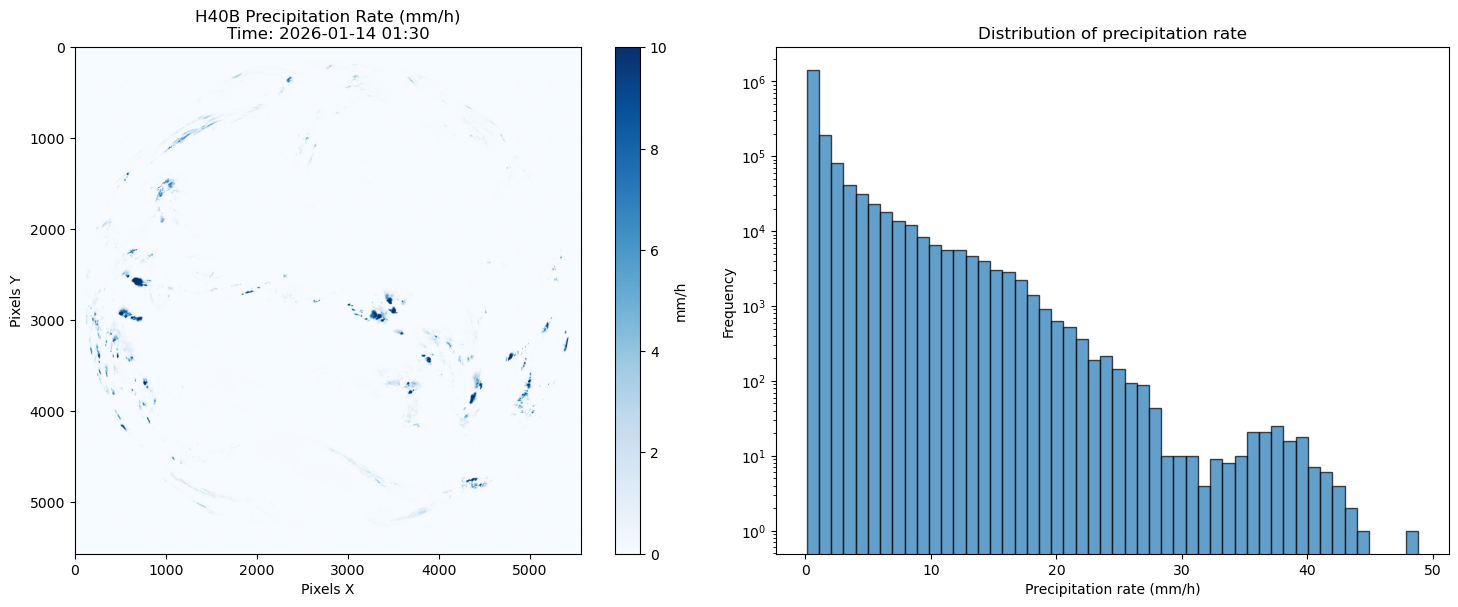


Precipitation statistics:
   Total pixels : 31,002,624
   Pixels with rain (>0 mm/h) : 1,858,131
   Rain coverage : 8.3%
   Maximum precipitation rate : 48.8 mm/h
   Mean precipitation rate (rainy areas) : 1.21 mm/h


In [29]:
def plot_raw_data(ds, filename=None):
    """Create a simple visualization of raw H40B data"""
    
    if ds is None:
        print("No dataset to display")
        return
    
    if filename is not None:
        match = re.search(r'(\d{8})_(\d{4})', filename)
        if match:
            date_str, time_str = match.groups()
            timestamp = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} {time_str[:2]}:{time_str[2:]}"
        else:
            timestamp = "Unknown"
    else:
        timestamp = "Unknown"

    print(f"Displaying data for file: {filename} (time: {timestamp})")

    rr = ds['rr']
    scale_factor = rr.encoding.get('scale_factor', 0.1)
    add_offset = rr.encoding.get('add_offset', 0.0)
    precip = rr.astype('float32') * scale_factor + add_offset
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    im1 = ax1.imshow(precip.values, cmap='Blues', vmin=0, vmax=10)
    ax1.set_title(f'H40B Precipitation Rate (mm/h)\nTime: {timestamp}')
    ax1.set_xlabel('Pixels X')
    ax1.set_ylabel('Pixels Y')
    plt.colorbar(im1, ax=ax1, label='mm/h')
    
    valid_precip = precip.values[precip.values >= 0]
    ax2.hist(valid_precip[valid_precip > 0], bins=50, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Precipitation rate (mm/h)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of precipitation rate')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPrecipitation statistics:")
    print(f"   Total pixels : {precip.size:,}")
    print(f"   Pixels with rain (>0 mm/h) : {np.sum(valid_precip > 0):,}")
    print(f"   Rain coverage : {100 * np.sum(valid_precip > 0) / len(valid_precip):.1f}%")
    print(f"   Maximum precipitation rate : {np.max(valid_precip):.1f} mm/h")
    print(f"   Mean precipitation rate (rainy areas) : {np.mean(valid_precip[valid_precip > 0]):.2f} mm/h")

plot_raw_data(raw_dataset, filename=Path(downloaded_file).name)

Note that the satellite grid is in pixels X and Y, not in latitude/longitude.
Each cell in the H40B file corresponds to a pixel from the MTG FCI satellite sensor.
If you want to use this data on a geographic map or with QGIS, it needs to be reprojected onto a latitude/longitude grid.

# Step 9: Preprocessing Data and reproject onto a Latitude/Longitude Grid

Main steps:
1. Load the raw H40B file.
2. Apply scale factors and rename the precipitation variable.
3. Extract MTG FCI projection parameters from the file.
4. Convert angular coordinates (radians) to projection coordinates (meters).
5. Reproject the data to WGS84 (latitude/longitude).
6. Set global and variable metadata.
7. Save the NetCDF file in the processed folder.

**Key difference from H60B:** MTG FCI stores coordinates as angular values (radians). We convert these to meters by multiplying with the satellite height, then reproject to lat/lon. This replaces the CGMS/satpy approach used for MSG SEVIRI in H60B.

In [30]:
def extract_mtg_projection_params(ds):
    """
    Extract projection parameters from an MTG FCI H40B file.
    
    H40B files may contain projection info in:
    - A 'geostationary_projection' variable (CF-compliant)
    - A 'gdal_projection' global attribute (PROJ4 string)
    
    If neither is found, standard MTG FCI defaults are used.
    """
    projection_params = {}
    
    # Try CF-compliant variable first
    if 'geostationary_projection' in ds.variables:
        geo_var = ds['geostationary_projection']
        param_mapping = {
            'perspective_point_height': 'h',
            'semi_major_axis': 'a',
            'semi_minor_axis': 'b',
            'longitude_of_projection_origin': 'lon_0',
            'latitude_of_projection_origin': 'lat_0',
            'sweep_angle_axis': 'sweep'
        }
        for cf_name, our_name in param_mapping.items():
            if cf_name in geo_var.attrs:
                projection_params[our_name] = geo_var.attrs[cf_name]
    
    # Fallback: try gdal_projection attribute
    if 'gdal_projection' in ds.attrs:
        gdal_proj = ds.attrs['gdal_projection']
        if isinstance(gdal_proj, str) and '+proj=geos' in gdal_proj:
            matches = re.findall(r'\+?(\w+)\s*=\s*([^\s]+)', gdal_proj)
            for key, val in matches:
                if key not in projection_params:
                    try:
                        projection_params[key] = float(val)
                    except ValueError:
                        projection_params[key] = val
    
    # MTG FCI defaults for any missing parameters
    mtg_defaults = {
        'h': 35785831,       # Standard geostationary height (meters)
        'a': 6378169,        # WGS84 semi-major axis (meters)
        'b': 6356584,        # WGS84 semi-minor axis (meters)
        'lon_0': 0.0,        # MTG-I1 at 0 degrees longitude
        'lat_0': 0.0,        # Standard for geostationary
        'sweep': 'y'         # MTG FCI sweep direction
    }
    for key, default_val in mtg_defaults.items():
        if key not in projection_params:
            projection_params[key] = default_val
    
    return projection_params

print("Projection extraction function defined.")

Projection extraction function defined.


In [31]:
def preprocess_single_file(raw_file: str, output_folder=None):
    """Preprocess a single H40B file for WGS84 with consistent variable names."""
    
    target_folder = Path(output_folder) if output_folder else processed_folder
    target_folder.mkdir(parents=True, exist_ok=True)

    filename = Path(raw_file).name

    timestamp = parse_h40b_timestamp(filename)
    hsaf_filename = f"HSAF-H40B_{timestamp.strftime('%Y%m%dT%H%M%S')}.nc"
    output_path = target_folder / hsaf_filename

    if output_path.exists():
        print(f"File already preprocessed: {hsaf_filename} -> Skipping preprocessing")
        return str(output_path)

    print(f"Preprocessing H40B file: {filename} -> {hsaf_filename}")
    
    crs_out = "EPSG:4326"

    ds = xr.open_dataset(raw_file, decode_coords="all", decode_cf=False)

    ds = ds.rename({"nx": "x", "ny": "y"})
    rr_raw = ds["rr"]
    scale_factor = rr_raw.encoding.get("scale_factor", 0.1)
    add_offset = rr_raw.encoding.get("add_offset", 0.0)
    ds["rr"] = rr_raw.astype("float32") * scale_factor + add_offset
    ds["rr"].encoding.clear()
    ds["rr"].attrs.clear()
    ds = ds[["rr"]].astype("float32")

    projection_params = extract_mtg_projection_params(ds)
    print(f"   MTG FCI projection params: h={projection_params['h']}, "
          f"a={projection_params['a']}, lon_0={projection_params['lon_0']}, "
          f"sweep={projection_params['sweep']}")

    x_angular = ds.x.values
    y_angular = ds.y.values
    satellite_height = float(projection_params["h"])

    x_proj = x_angular * satellite_height
    y_proj = y_angular * satellite_height

    ds = ds.assign_coords(x=("x", x_proj), y=("y", y_proj))

    crs_string = (
        f"+proj=geos +h={projection_params['h']} "
        f"+a={projection_params['a']} +b={projection_params['b']} "
        f"+lon_0={projection_params['lon_0']} +sweep={projection_params['sweep']} +units=m"
    )
    ds = ds.rio.write_crs(crs_string)

    ds = ds.rename({"rr": "precip_intensity"}).sortby("y")

    ds = ds.expand_dims("time").assign_coords(time=("time", [timestamp]))
    ds = ds.transpose("time", "y", "x")

    ds.precip_intensity.attrs = {
        "standard_name": "precipitation_flux",
        "long_name": "Precipitation Flux derived from MTG FCI observations",
        "units": "kg m-2 h-1",
    }

    ds["precip_intensity"] = ds["precip_intensity"].where(ds["precip_intensity"] >= 0, np.nan)

    for var_name in ds.data_vars:
        ds[var_name].encoding.clear()
        for attr in ["_FillValue", "missing_value", "fill_value", "FillValue"]:
            ds[var_name].attrs.pop(attr, None)

    print("Before reprojection: min/max", float(ds.precip_intensity.min()), float(ds.precip_intensity.max()))

    print("Reprojecting H40B data to WGS84")
    ds = ds.rio.reproject(crs_out)

    print("After reprojection: min/max", float(ds.precip_intensity.min(skipna=True)), float(ds.precip_intensity.max(skipna=True)))

    for var_name in ds.data_vars:
        ds[var_name].encoding.clear()
        for attr in ["_FillValue", "missing_value", "fill_value", "FillValue"]:
            ds[var_name].attrs.pop(attr, None)

    ds = ds.transpose("time", "y", "x")

    ds.x.attrs = {"standard_name": "longitude", "long_name": "longitude", "units": "degrees_east", "axis": "X"}
    ds.y.attrs = {"standard_name": "latitude", "long_name": "latitude", "units": "degrees_north", "axis": "Y"}
    ds.time.attrs = {"standard_name": "time", "long_name": "time", "axis": "T"}

    ds.attrs = {
        "Conventions": "CF-1.6",
        "title": "H-SAF H40B MTG FCI Precipitation",
        "source": "EUMETSAT H-SAF H40B",
        "satellite": "MTG-I1",
        "instrument": "FCI",
        "creator": "WMO Workshop",
        "creation_date": date.today().strftime("%Y-%m-%d"),
        "time_coverage_start": timestamp.strftime("%Y-%m-%dT%H:%M:%S"),
        "time_coverage_end": (timestamp + timedelta(minutes=10)).strftime("%Y-%m-%dT%H:%M:%S"),
        "geospatial_lat_min": float(ds.y.min()),
        "geospatial_lat_max": float(ds.y.max()),
        "geospatial_lon_min": float(ds.x.min()),
        "geospatial_lon_max": float(ds.x.max()),
        "crs": crs_out,
        "product_details": "https://hsaf.meteoam.it/Products/Detail?prod=H40B",
        "data_source": "hsaf-h40b",
    }

    encoding = {
        "precip_intensity": {"dtype": "float32", "zlib": True, "complevel": 4, "_FillValue": -999.0},
        "time": {"units": "minutes since 1970-01-01 00:00:00", "dtype": "float64"},
    }

    ds.to_netcdf(output_path, encoding=encoding)
    ds.close()
    print(f"H40B file successfully preprocessed: {hsaf_filename}")
    return str(output_path)

# Run preprocessing for the downloaded file
processed_file = preprocess_single_file(downloaded_file)

Preprocessing H40B file: h40_20260114_0130_fdk.nc -> HSAF-H40B_20260114T013000.nc
   MTG FCI projection params: h=35785831.0, a=6378169.0, lon_0=0.0, sweep=y
Before reprojection: min/max 0.0 48.79999923706055
Reprojecting H40B data to WGS84
After reprojection: min/max 0.0 43.70000076293945
H40B file successfully preprocessed: HSAF-H40B_20260114T013000.nc


# Step 10: Visualizing Preprocessed Data in Latitude and Longitude
Now, we will create two plots to analyse the preprocessed data results:
1. A full precipitation map (mm/h).
2. A precipitation map which highlights only the rainy areas (> 0.1 mm/h).

At the same time, we will display some statistics to better analyse the data quality and coverage:
- The size of the used grid
- The number of valid pixels
- The number and coverage of rainy pixels
- Maximum and mean precipitation intensity in rainy areas

<xarray.Dataset> Size: 124MB
Dimensions:           (x: 5702, y: 5431, time: 1)
Coordinates:
  * x                 (x) float64 46kB -81.25 -81.22 -81.19 ... 81.22 81.25
  * y                 (y) float64 43kB 77.38 77.36 77.33 ... -77.36 -77.39
  * time              (time) datetime64[ns] 8B 2026-01-14T01:30:00
    spatial_ref       int64 8B ...
Data variables:
    precip_intensity  (time, y, x) float32 124MB ...
Attributes: (12/16)
    Conventions:          CF-1.6
    title:                H-SAF H40B MTG FCI Precipitation
    source:               EUMETSAT H-SAF H40B
    satellite:            MTG-I1
    instrument:           FCI
    creator:              WMO Workshop
    ...                   ...
    geospatial_lat_max:   77.38379302114228
    geospatial_lon_min:   -81.24829056432118
    geospatial_lon_max:   81.25032259881716
    crs:                  EPSG:4326
    product_details:      https://hsaf.meteoam.it/Products/Detail?prod=H40B
    data_source:          hsaf-h40b


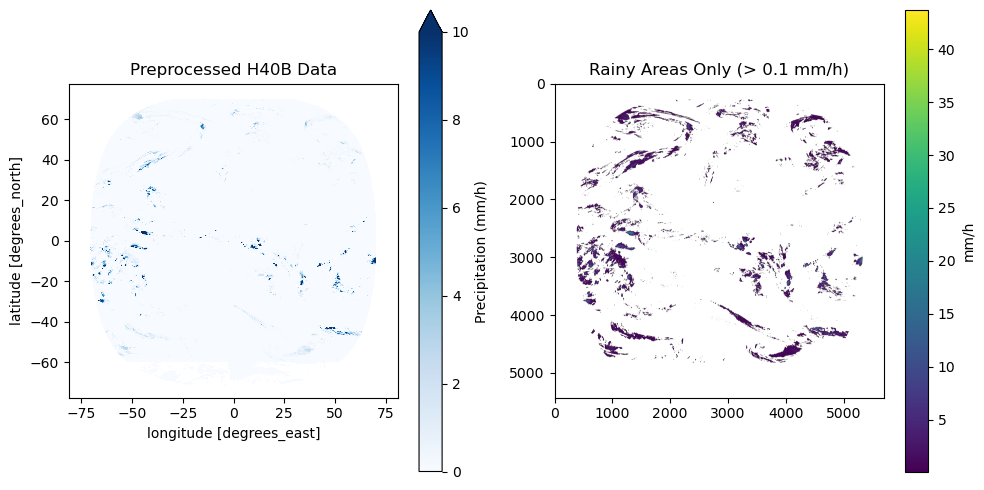


Summary of preprocessed data:
   Time : 2026-01-14T01:30:00.000000000
   Grid size : 5431 x 5702 pixels
   Valid pixels : 20,981,412
   Rainy pixels (>0.1 mm/h) : 1,579,823
   Rain coverage : 7.53%
   Maximum intensity : 43.7 mm/h
   Mean intensity (rainy areas) : 1.45 mm/h


In [32]:
def plot_processed_data(processed_file):
    """Visualize preprocessed precipitation data"""
    
    ds = xr.open_dataset(processed_file)
    print(ds)
    
    precip = ds["precip_intensity"].isel(time=0)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = precip.plot(ax=ax1, cmap='Blues', vmin=0, vmax=10,
                      cbar_kwargs={'label': 'Precipitation (mm/h)'})
    ax1.set_title('Preprocessed H40B Data')
    ax1.set_aspect('equal')
    
    rain_mask = precip.values > 0.1
    if np.any(rain_mask):
        im2 = ax2.imshow(np.where(rain_mask, precip.values, np.nan),
                         cmap='viridis', vmin=0.1)
        ax2.set_title('Rainy Areas Only (> 0.1 mm/h)')
        plt.colorbar(im2, ax=ax2, label='mm/h')
    else:
        ax2.text(0.5, 0.5, 'No significant\nrain detected',
                 ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Rainy Areas Only')
    
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    valid_data = precip.values[precip.values >= 0]
    rainy_data = valid_data[valid_data > 0.1]
    
    print(f"\nSummary of preprocessed data:")
    print(f"   Time : {ds.time.values[0]}")
    print(f"   Grid size : {precip.shape[0]} x {precip.shape[1]} pixels")
    print(f"   Valid pixels : {len(valid_data):,}")
    print(f"   Rainy pixels (>0.1 mm/h) : {len(rainy_data):,}")
    print(f"   Rain coverage : {100 * len(rainy_data) / len(valid_data):.2f}%")
    
    if len(rainy_data) > 0:
        print(f"   Maximum intensity : {np.max(rainy_data):.1f} mm/h")
        print(f"   Mean intensity (rainy areas) : {np.mean(rainy_data):.2f} mm/h")

if processed_file is not None:
    plot_processed_data(processed_file)

Note: You can observe the effect of the reprojecting process. In the left image the data shows a more round data coverage compared to the raw data visualization.

# Step 11: Final Operational Loop
We have now observed in detail how the pre-processing is organized for one single file/timestep.
The next step combines all previous steps into a single loop for efficient pre-processing over a number of timesteps:
1. Download the file from the FTP server
2. Preprocess the file to convert it into a latitude/longitude grid
3. Save the processed file to the appropriate folder

In [33]:
# Earlier in this notebook, you selected a time period of interest for analyzing HSAF data.
# These files will now be used in the following loop. The selected time steps are:
selected_files

['h40_20260114_0000_fdk.nc.gz',
 'h40_20260114_0010_fdk.nc.gz',
 'h40_20260114_0020_fdk.nc.gz',
 'h40_20260114_0030_fdk.nc.gz',
 'h40_20260114_0040_fdk.nc.gz',
 'h40_20260114_0050_fdk.nc.gz',
 'h40_20260114_0100_fdk.nc.gz',
 'h40_20260114_0110_fdk.nc.gz',
 'h40_20260114_0120_fdk.nc.gz',
 'h40_20260114_0130_fdk.nc.gz']

In [34]:
# Final loop to download and preprocess the selected files
for selected_file in selected_files:
    downloaded_file = download_h40b_file(selected_file)
    
    timestamp = parse_h40b_timestamp(Path(downloaded_file).name)
    hsaf_filename = f"HSAF-H40B_{timestamp.strftime('%Y%m%dT%H%M%S')}.nc"
    output_path = processed_folder / hsaf_filename

    if output_path.exists():
        print(f"{hsaf_filename} already exists, skipping to next file\n" + "-"*40)
        continue

    preprocess_single_file(downloaded_file)
    print(f"{selected_file} processed\n" + "-"*40)

Downloaded h40_20260114_0000_fdk.nc.gz (3.3 MB)
Decompressing the file...
Decompressed to h40_20260114_0000_fdk.nc (3.4 MB)
Preprocessing H40B file: h40_20260114_0000_fdk.nc -> HSAF-H40B_20260114T000000.nc
   MTG FCI projection params: h=35785831.0, a=6378169.0, lon_0=0.0, sweep=y
Before reprojection: min/max 0.0 46.400001525878906
Reprojecting H40B data to WGS84
After reprojection: min/max 0.0 46.400001525878906
H40B file successfully preprocessed: HSAF-H40B_20260114T000000.nc
h40_20260114_0000_fdk.nc.gz processed
----------------------------------------
Downloaded h40_20260114_0010_fdk.nc.gz (3.3 MB)
Decompressing the file...
Decompressed to h40_20260114_0010_fdk.nc (3.4 MB)
Preprocessing H40B file: h40_20260114_0010_fdk.nc -> HSAF-H40B_20260114T001000.nc
   MTG FCI projection params: h=35785831.0, a=6378169.0, lon_0=0.0, sweep=y
Before reprojection: min/max 0.0 40.70000076293945
Reprojecting H40B data to WGS84
After reprojection: min/max 0.0 40.70000076293945
H40B file successfully 

# Step 12: Selecting and Analyzing HSAF Data for a Specific Area
The HSAF files have been downloaded for a very large area. Now, we will zoom in and analyze the data for a specific area of interest,
using latitude and longitude coordinates to define your region of interest.

In [35]:
# Available time steps in the folder containing preprocessed HSAF precipitation data.
file_list = sorted(processed_folder.glob("HSAF-H40B_*.nc"))
for f in file_list:
    print(f.name)

HSAF-H40B_20260114T000000.nc
HSAF-H40B_20260114T001000.nc
HSAF-H40B_20260114T002000.nc
HSAF-H40B_20260114T003000.nc
HSAF-H40B_20260114T004000.nc
HSAF-H40B_20260114T005000.nc
HSAF-H40B_20260114T010000.nc
HSAF-H40B_20260114T011000.nc
HSAF-H40B_20260114T012000.nc
HSAF-H40B_20260114T013000.nc


In [36]:
def plot_h40b_subset(processed_folder, filename=None, start_time=None, end_time=None, region=None, max_cols=5):
    """
    Visualize preprocessed H40B data for a given region.
    - filename : display a specific file
    - start_time / end_time : display all time steps in this interval
    - region : dictionary with lat_min, lat_max, lon_min, lon_max
    - max_cols : maximum number of columns per row for subplots
    """
    if filename is not None:
        ds = xr.open_dataset(processed_folder / filename)
    else:
        ds = xr.open_mfdataset(str(processed_folder / "HSAF-H40B_*.nc"))
    
    if region is None:
        region = {"lat_min": -12, "lat_max": 22, "lon_min": 21, "lon_max": 55}
    
    ds_roi = ds.sel(
        x=slice(region["lon_min"], region["lon_max"]),
        y=slice(region["lat_max"], region["lat_min"])
    )
    
    if start_time is not None and end_time is not None:
        ds_roi = ds_roi.sel(time=slice(start_time, end_time))
    
    bounds = [0, 0.5, 2, 5, 10, 15, 25, 40, 100]
    colors = ["#ffffff", "#add8e6", "#0000ff", "#00ff00",
              "#ffff00", "#ffa500", "#ff0000", "#ff69b4"]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    n_times = len(ds_roi.time)
    n_cols = min(n_times, max_cols)
    n_rows = math.ceil(n_times / max_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), subplot_kw={'projection': ccrs.PlateCarree()})
    axes = np.array(axes).ravel()

    for t in range(n_times):
        ax = axes[t]
        subset = ds_roi.precip_intensity.isel(time=t)
        
        ax.add_feature(cfeature.BORDERS, linewidth=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        
        im = ax.pcolormesh(subset.x, subset.y, subset.values,
                           cmap=cmap, norm=norm, shading='auto')
        cbar = plt.colorbar(im, ax=ax, orientation='vertical', label='Precipitation (mm/h)')
        cbar.set_ticks(bounds)
        cbar.set_ticklabels([str(b) for b in bounds])
        
        ax.set_extent([region["lon_min"], region["lon_max"],
                       region["lat_min"], region["lat_max"]])
        
        time_str = np.datetime_as_string(subset.time.values, unit='m')
        ax.set_title(time_str)
    
    for t in range(n_times, n_rows*n_cols):
        axes[t].axis('off')
    
    plt.tight_layout()
    plt.show()

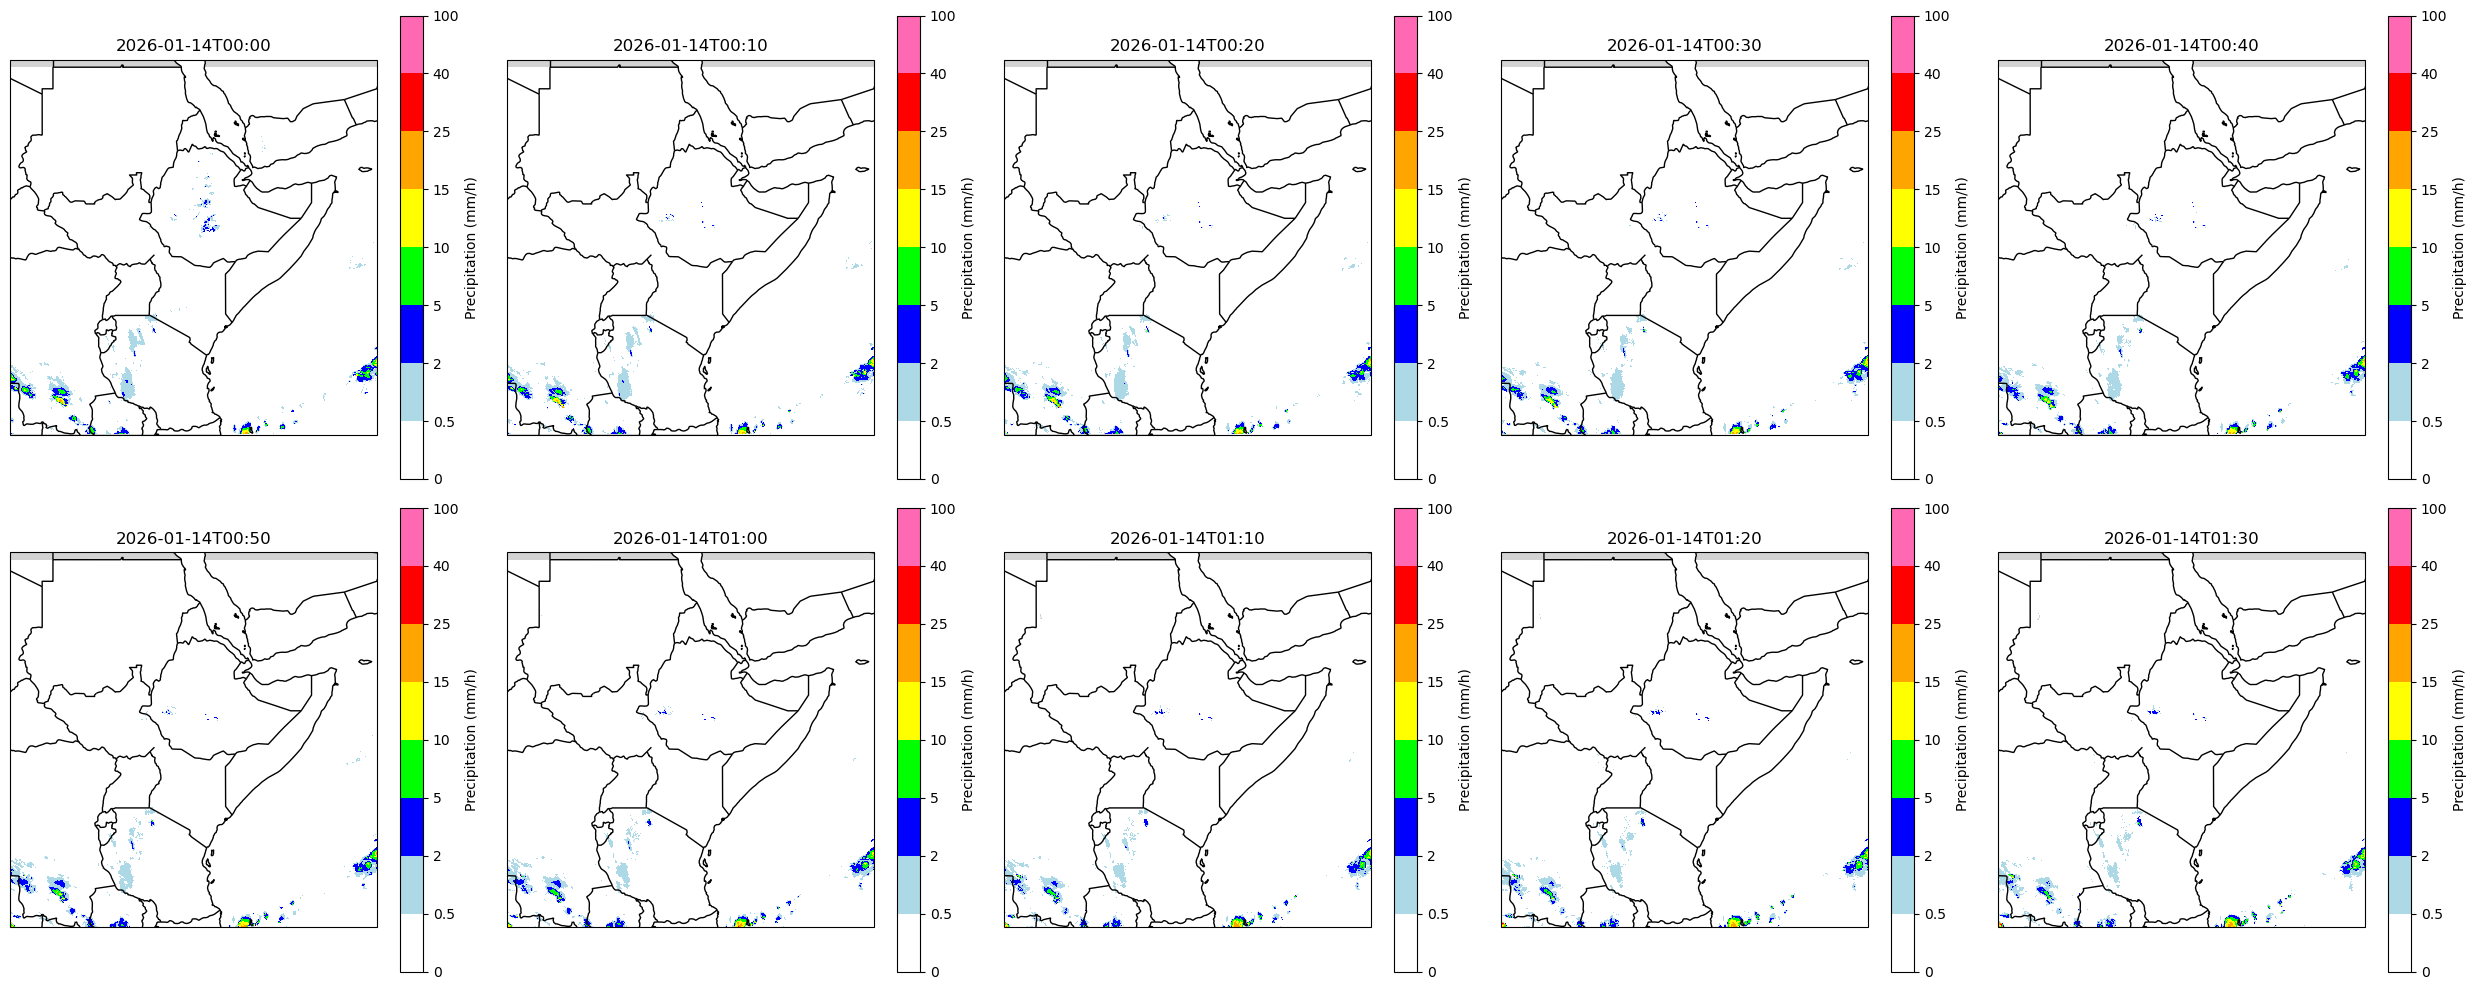

In [37]:
# Here, we call the visualization function for a specific time step.
plot_h40b_subset(processed_folder)

# Step 13: Extract HSAF precipitation for specific points

In [38]:
# 1. Define the folder containing the preprocessed HSAF files
processed_folder = Path("h40b_data/processed/")

# 2. Define points of interest (latitude and longitude)
points = [
    {"name": "Kigali", "lat": -1.9441, "lon": 30.0619},
    {"name": "Juba", "lat": 4.8594, "lon": 31.5713},
    {"name": "Khartoum", "lat": 15.5007, "lon": 32.5599},
    {"name": "Kampala", "lat": 0.3476, "lon": 32.5825},
    {"name": "Addis Ababa", "lat": 8.9806, "lon": 38.7578},
]

# 3. Load all preprocessed HSAF files
ds = xr.open_mfdataset(str(processed_folder / "HSAF-H40B_*.nc"))

# 4. Extract time series for each point
data_dict = {}

for pt in points:
    rain_series = ds.sel(
        x=ds["x"].sel(x=pt["lon"], method="nearest"),
        y=ds["y"].sel(y=pt["lat"], method="nearest")
    )["precip_intensity"]
    
    data_dict[pt["name"]] = rain_series.values

# 5. Create a DataFrame: rows = timestamps, columns = points
df_points = pd.DataFrame(data_dict, index=rain_series["time"].values)
df_points.index.name = "time"

# 6. Display the final DataFrame
print("Final DataFrame: each column is a point, each row is a timestamp")
df_points

Final DataFrame: each column is a point, each row is a timestamp


,Kigali,Juba,Khartoum,Kampala,Addis Ababa
time,,,,,
2026-01-14 00:00:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 00:10:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 00:20:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 00:30:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 00:40:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 00:50:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 01:00:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 01:10:00,0.0,0.0,0.0,0.0,0.0
2026-01-14 01:20:00,0.0,0.0,0.0,0.0,0.0


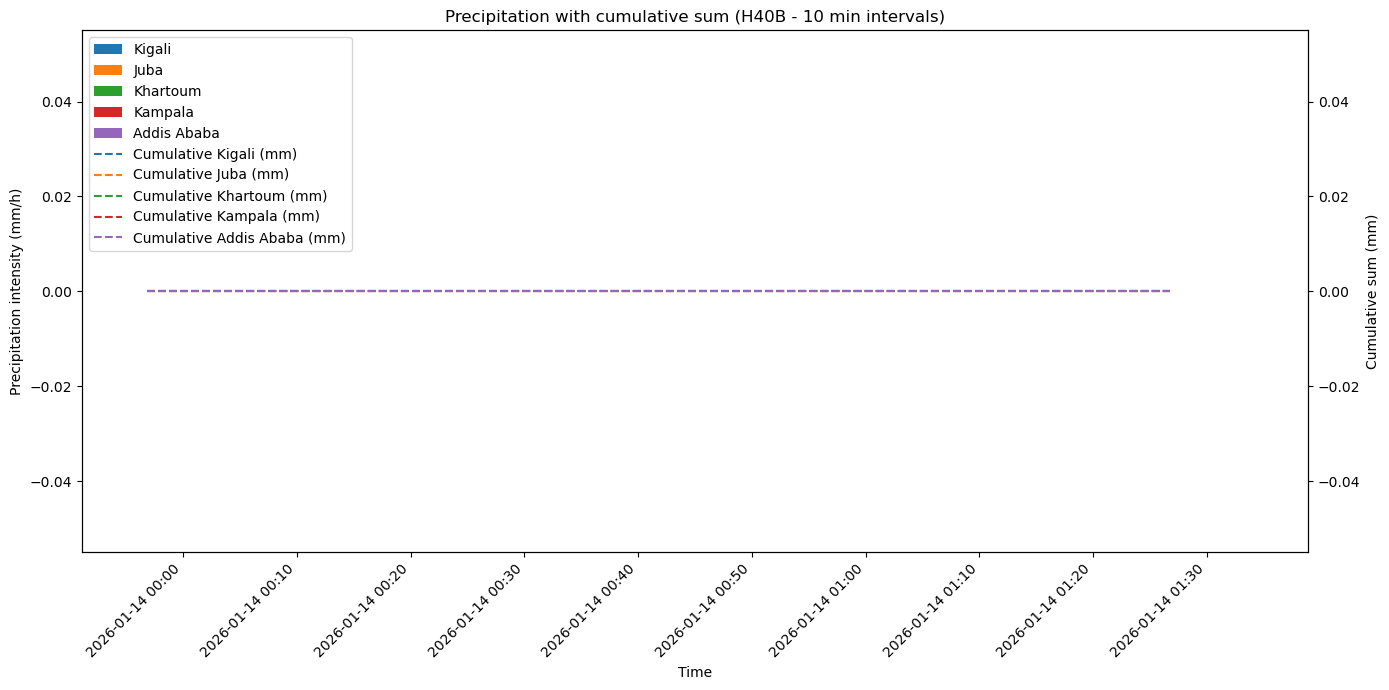

In [39]:
df_date = df_points

fig, ax1 = plt.subplots(figsize=(14, 7))

x = np.arange(len(df_date.index))
n_locations = len(df_date.columns)
width = 0.8 / n_locations

for i, col in enumerate(df_date.columns):
    ax1.bar(
        x + i * width,
        df_date[col].values,
        width=width,
        label=col
    )

ax1.set_xticks(x + width * (n_locations - 1) / 2)
ax1.set_xticklabels(df_date.index.strftime("%Y-%m-%d %H:%M"), rotation=45, ha="right")
ax1.set_ylabel("Precipitation intensity (mm/h)")
ax1.set_xlabel("Time")

# Convert to mm per 10-minute step (H40B interval)
df_mm = df_date * (10 / 60)  # mm/h * (10/60) = mm per 10 minutes

ax2 = ax1.twinx()
for col in df_mm.columns:
    ax2.plot(
        x,
        df_mm[col].cumsum(), linestyle="--", label=f"Cumulative {col} (mm)"
    )
ax2.set_ylabel("Cumulative sum (mm)")

lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left")

plt.title(f"Precipitation with cumulative sum (H40B - 10 min intervals)")
plt.tight_layout()
plt.show()

# Congratulations, you have successfully downloaded the EUMETSAT H SAF H40B data! 🎉